# 1. Closed Queuing network simulation (17 pt)
Build a simulator to capture the following system and answer the questions below. A total of N=40 jobs circulate in different parts of the systems: CPU, disk, and resting area. There is one CPU and two disks, one slow and one fast. Each job starts at the CPU station and takes an average of 2 seconds. After CPU, a job fetches the data from the disk, needing an average of 3000 disk cycles. There are two possible choices of disks, fast and slow, which have a speed of 1000 cycles per second and 100 cycles per seconds, respectively. After the disk station, the job can rest for 15 seconds on average. The figure below gives an overview of the system:


![image](Queued.png)

The choices of distributions are up to you. You are welcomed to try different distributions to answer the following questions and assess the impact of different variants.


Questions:
(3p) What will be the maximal system throughput in terms of number of jobs, given two different load balancing strategies for sending jobs between the fast and slow disk? You need to come up with two load balancing strategies and compare them. 
(3p) What will the system throughput and average response time of a job be if a faster CPU is used? Say, CPU time is reduced to 1 seconds on average and the rest of the system remains the same.
(3p) What will the system throughput and average response time of a job be if a second fast disk is added? Again, you need to compare the throughput under two different load balancing strategies.
(3p) What will the system throughput and average response time of a job be if a faster CPU is used and a second fast disk is added? And, you use the better load balancing strategies out of two you propose in the first question?
(5pt) If you can answer all the above questions with different number of N and plot them in the following style:


![image](Graph.png)

In [59]:
# imports
import os
import sys
from contextlib import contextmanager, redirect_stdout
from typing import Literal, Generator

import matplotlib.pyplot as plt
import numpy as np
import simpy
from matplotlib.axes import Axes
from matplotlib.figure import Figure

RNG = np.random.default_rng(seed=0)

@contextmanager
def suppress_print():
    """Temporarily disable print statements."""
    with redirect_stdout(open(os.devnull, "w")):
        yield

In [60]:
# baseline simulator
class ClosedQueueNetwork:
    """Closed queueing network with CPU and two disks (fast/slow)."""
    
    def __init__(self, N_jobs: int = 40) -> None:
        self.env = simpy.Environment()
        self.cpu = simpy.Resource(self.env, capacity=1)
        self.slow_disk = simpy.Resource(self.env, capacity=1)
        self.fast_disk = simpy.Resource(self.env, capacity=1)
        self.N_jobs = N_jobs
        
        # Service time scale parameters
        self.beta_cpu = 2.0
        self.beta_fast_disk = 3.0
        self.beta_slow_disk = 30.0
        self.beta_rest = 15.0

    def job_generator(self, job_id: int) -> Generator:
        """Process loop for a single job in the closed network."""
        while True:
            # CPU phase
            with self.cpu.request() as request:
                yield request
                yield self.env.timeout(RNG.exponential(scale=self.beta_cpu))

            # Disk phase: randomly select fast or slow (50/50)
            if RNG.random() < 0.5:
                # Fast disk
                with self.fast_disk.request() as request:
                    yield request
                    yield self.env.timeout(RNG.exponential(scale=self.beta_fast_disk))
            else:
                # Slow disk
                with self.slow_disk.request() as request:
                    yield request
                    yield self.env.timeout(RNG.exponential(scale=self.beta_slow_disk))
            
            # Rest phase (think time)
            yield self.env.timeout(RNG.exponential(scale=self.beta_rest))

    def run(self, until: float = 1000) -> "ClosedQueueNetwork":
        """Run simulation until specified time."""
        for i in range(self.N_jobs):
            self.env.process(self.job_generator(i))
        self.env.run(until=until)
        return self


In [61]:
ClosedQueueNetwork(N_jobs=40).run(until=1000)

In [62]:
# Question 1: Load Balancing Strategy Comparison

from typing import Generator
import numpy as np
import simpy

RNG = np.random.default_rng(seed=0)

class ClosedQueueNetwork:
    def __init__(self, N_jobs: int = 40, strategy: str = "random") -> None:
        self.env = simpy.Environment()
        self.cpu = simpy.Resource(self.env, capacity=1)
        self.slow_disk = simpy.Resource(self.env, capacity=1)
        self.fast_disk = simpy.Resource(self.env, capacity=1)
        
        self.N_jobs = N_jobs
        self.strategy = strategy
        
        # Throughput tracking
        self.completed_cycles = 0
        
        # Utilization tracking
        self.cpu_busy_time = 0.0
        self.disk_fast_busy_time = 0.0
        self.disk_slow_busy_time = 0.0
        
        # Probability for proportional strategy
        self.fast_prob = 1000 / (1000 + 100)

    def job_generator(self, job_id: int) -> Generator:
        while True:
            # CPU phase
            with self.cpu.request() as request:
                yield request
                cpu_service = RNG.exponential(2.0)
                self.cpu_busy_time += cpu_service
                yield self.env.timeout(cpu_service)

            # Disk choice based on strategy
            use_fast = self._select_disk()

            # Disk service
            if use_fast:
                with self.fast_disk.request() as request:
                    yield request
                    disk_service = RNG.exponential(3.0)
                    self.disk_fast_busy_time += disk_service
                    yield self.env.timeout(disk_service)
            else:
                with self.slow_disk.request() as request:
                    yield request
                    disk_service = RNG.exponential(30.0)
                    self.disk_slow_busy_time += disk_service
                    yield self.env.timeout(disk_service)

            # Rest phase
            yield self.env.timeout(RNG.exponential(15.0))
            self.completed_cycles += 1

    def _select_disk(self) -> bool:
        if self.strategy == "random":
            return RNG.random() < 0.5
        elif self.strategy == "proportional":
            return RNG.random() < self.fast_prob
        elif self.strategy == "jsq":
            # This is the jsq thingy
            fast_len = len(self.fast_disk.queue)
            slow_len = len(self.slow_disk.queue)
            return fast_len <= slow_len
        else:
            raise ValueError(f"Unknown strategy: {self.strategy}")

    def run(self, until: float = 100000) -> "ClosedQueueNetwork":
        for i in range(self.N_jobs):
            self.env.process(self.job_generator(i))
        self.env.run(until=until)
        return self

    def system_throughput(self) -> float:
        return self.completed_cycles / self.env.now

    def utilization(self) -> dict:
        total_time = self.env.now
        return {
            "cpu": self.cpu_busy_time / total_time,
            "disk_fast": self.disk_fast_busy_time / total_time,
            "disk_slow": self.disk_slow_busy_time / total_time,
        }


def question_1_comparison(
    N_values: list = None,
    n_reps: int = 5,
    sim_length: float = 100000,
) -> tuple:    
    if N_values is None:
        N_values = [10, 20, 40, 80, 160]
    
    strategies = ["random", "proportional", "jsq"]
    results = {s: [] for s in strategies}
    
    for strategy in strategies:
        for N in N_values:
            throughputs = []
            
            for _ in range(n_reps):
                net = ClosedQueueNetwork(N_jobs=N, strategy=strategy)
                net.run(until=sim_length)
                throughputs.append(net.system_throughput())
            
            results[strategy].append({
                "N": N,
                "mean": np.mean(throughputs),
                "std": np.std(throughputs),
                "min": np.min(throughputs),
                "max": np.max(throughputs),
            })
    
    # Identify best strategies
    max_throughputs = {
        s: max([r["mean"] for r in results[s]]) for s in strategies
    }
    sorted_strategies = sorted(strategies, key=lambda s: max_throughputs[s], reverse=True)
    best_two = sorted_strategies[:2]
    
    return results, max_throughputs, best_two


if __name__ == "__main__":
    results, max_thrs, best_strats = question_1_comparison()
    
    print("### Results Summary")
    print(f"Top Strategy:  {best_strats[0]} (Max X: {max_thrs[best_strats[0]]:.4f})")
    print(f"Runner Up:     {best_strats[1]} (Max X: {max_thrs[best_strats[1]]:.4f})")


### Results Summary
Top Strategy:  jsq (Max X: 0.3675)
Runner Up:     proportional (Max X: 0.3661)


In [63]:
# Question 2: Faster CPU Impact
class ClosedQueueNetwork:    
    def __init__(self, N_jobs: int = 40, strategy: str = "jsq", cpu_mean: float = 1.0) -> None:
        self.env = simpy.Environment()
        self.cpu = simpy.Resource(self.env, capacity=1)
        self.slow_disk = simpy.Resource(self.env, capacity=1)
        self.fast_disk = simpy.Resource(self.env, capacity=1)
        
        self.N_jobs = N_jobs
        self.strategy = strategy
        
        # Service time scale parameters
        self.beta_cpu = cpu_mean # Reduced to 1.0s for Q2
        self.beta_fast_disk = 3.0
        self.beta_slow_disk = 30.0
        self.beta_rest = 15.0
        
        # Throughput tracking
        self.completed_cycles = 0
        
    def job_generator(self, job_id: int) -> Generator:
        while True:
            # CPU phase
            with self.cpu.request() as request:
                yield request
                yield self.env.timeout(RNG.exponential(scale=self.beta_cpu))

            # Disk choice based on JSQ (best strategy from Q1)
            use_fast = self._select_disk()

            # Disk service
            if use_fast:
                with self.fast_disk.request() as request:
                    yield request
                    yield self.env.timeout(RNG.exponential(scale=self.beta_fast_disk))
            else:
                with self.slow_disk.request() as request:
                    yield request
                    yield self.env.timeout(RNG.exponential(scale=self.beta_slow_disk))

            # Rest phase
            yield self.env.timeout(RNG.exponential(scale=self.beta_rest))
            self.completed_cycles += 1

    def _select_disk(self) -> bool:
        fast_len = len(self.fast_disk.queue)
        slow_len = len(self.slow_disk.queue)
        return fast_len <= slow_len

    def run(self, until: float = 100000) -> "ClosedQueueNetwork":
        for i in range(self.N_jobs):
            self.env.process(self.job_generator(i))
        self.env.run(until=until)
        return self

    def system_throughput(self) -> float:
        return self.completed_cycles / self.env.now

    def average_response_time(self) -> float:
        X = self.system_throughput()
        if X > 0:
            return (self.N_jobs / X) - self.beta_rest
        return 0.0

def question_2_analysis(N_values: list = None, n_reps: int = 5, sim_length: float = 100000) -> None:    
    if N_values is None:
        N_values = [10, 20, 40, 80, 160]

    print("### Question 2: Faster CPU (1s mean)")
    print(f"Strategy: JSQ (Best from Q1)")
    # we can print in a cool style like this so it's like a table 
    print(f"{'N':>6} | {'Throughput (X)':>16} | {'Response Time (E[R])':>22}")
    
    for N in N_values:
        throughputs = []
        response_times = []
        
        for _ in range(n_reps):
            net = ClosedQueueNetwork(N_jobs=N, strategy="jsq", cpu_mean=1.0)
            net.run(until=sim_length)
            
            X = net.system_throughput()
            R = net.average_response_time()
            
            throughputs.append(X)
            response_times.append(R)
        
        avg_X = np.mean(throughputs)
        avg_R = np.mean(response_times)
        
        print(f"{N:>6} | {avg_X:>16.4f} | {avg_R:>22.2f}s")

if __name__ == "__main__":
    question_2_analysis()


### Question 2: Faster CPU (1s mean)
Strategy: JSQ (Best from Q1)
     N |   Throughput (X) |   Response Time (E[R])
    10 |           0.3060 |                  17.68s
    20 |           0.3648 |                  39.82s
    40 |           0.3672 |                  93.93s
    80 |           0.3662 |                 203.47s
   160 |           0.3663 |                 421.85s


In [64]:
# Question 3: Second Fast Disk Impact

class ClosedQueueNetwork:
    def __init__(self, N_jobs=40, cpu_mean=2.0, num_fast_disks=1):
        self.env = simpy.Environment()
        self.cpu = simpy.Resource(self.env, capacity=1)
        self.slow_disk = simpy.Resource(self.env, capacity=1)
        
        self.fast_disks = [simpy.Resource(self.env, capacity=1) for _ in range(num_fast_disks)]
        
        self.N_jobs = N_jobs
        self.num_fast_disks = num_fast_disks
        self.beta_cpu = cpu_mean
        self.beta_fast_disk = 3.0
        self.beta_slow_disk = 30.0
        self.beta_rest = 15.0
        
        self.completed_cycles = 0
        
    def job_generator(self, job_id):
        while True:
            with self.cpu.request() as req:
                yield req
                yield self.env.timeout(RNG.exponential(scale=self.beta_cpu))

            disk, is_fast = self._select_disk()
            
            with disk.request() as req:
                yield req
                if is_fast:
                    yield self.env.timeout(RNG.exponential(scale=self.beta_fast_disk))
                else:
                    yield self.env.timeout(RNG.exponential(scale=self.beta_slow_disk))

            yield self.env.timeout(RNG.exponential(scale=self.beta_rest))
            self.completed_cycles += 1

    def _select_disk(self):
        # JSQ: pick shortest queue
        fast_qs = [len(d.queue) for d in self.fast_disks]
        slow_q = len(self.slow_disk.queue)
        
        best_fast = min(fast_qs)
        best_idx = fast_qs.index(best_fast)
        
        if best_fast <= slow_q:
            return self.fast_disks[best_idx], True
        else:
            return self.slow_disk, False

    def run(self, until=100000):
        for i in range(self.N_jobs):
            self.env.process(self.job_generator(i))
        self.env.run(until=until)

    def get_throughput(self):
        return self.completed_cycles / self.env.now

    def get_response_time(self):
        X = self.get_throughput()
        if X > 0:
            return (self.N_jobs / X) - self.beta_rest
        return 0


def question_3():
    N_list = [10, 20, 40, 80, 160]
    reps = 5
    runtime = 100000
    
    print("\nQ3: Impact of 2nd Fast Disk\n")
    
    # Test with 1 disk
    print("1 Fast Disk:")
    for N in N_list:
        X_vals = []
        R_vals = []
        for _ in range(reps):
            net = ClosedQueueNetwork(N_jobs=N, cpu_mean=2.0, num_fast_disks=1)
            net.run(until=runtime)
            X_vals.append(net.get_throughput())
            R_vals.append(net.get_response_time())
        
        X_avg = np.mean(X_vals)
        R_avg = np.mean(R_vals)
        print(f"  N={N:3d}: X={X_avg:.4f}, R={R_avg:.1f}s")
    
    # Test with 2 disks
    print("\n2 Fast Disks:")
    for N in N_list:
        X_vals = []
        R_vals = []
        for _ in range(reps):
            net = ClosedQueueNetwork(N_jobs=N, cpu_mean=2.0, num_fast_disks=2)
            net.run(until=runtime)
            X_vals.append(net.get_throughput())
            R_vals.append(net.get_response_time())
        
        X_avg = np.mean(X_vals)
        R_avg = np.mean(R_vals)
        print(f"  N={N:3d}: X={X_avg:.4f}, R={R_avg:.1f}s")
    
    # Comparison at N=160
    print("\n--- At N=160 ---")
    
    X1_vals = []
    R1_vals = []
    for _ in range(reps):
        net = ClosedQueueNetwork(N_jobs=160, cpu_mean=2.0, num_fast_disks=1)
        net.run(until=runtime)
        X1_vals.append(net.get_throughput())
        R1_vals.append(net.get_response_time())
    
    X2_vals = []
    R2_vals = []
    for _ in range(reps):
        net = ClosedQueueNetwork(N_jobs=160, cpu_mean=2.0, num_fast_disks=2)
        net.run(until=runtime)
        X2_vals.append(net.get_throughput())
        R2_vals.append(net.get_response_time())
    
    X1_avg = np.mean(X1_vals)
    X2_avg = np.mean(X2_vals)
    R1_avg = np.mean(R1_vals)
    R2_avg = np.mean(R2_vals)
    
    print(f"1 disk: X={X1_avg:.4f}, R={R1_avg:.1f}s")
    print(f"2 disks: X={X2_avg:.4f}, R={R2_avg:.1f}s")
    
    x_gain = ((X2_avg - X1_avg) / X1_avg) * 100
    r_gain = ((R1_avg - R2_avg) / R1_avg) * 100
    
    print(f"\nGain: X +{x_gain:.1f}%, R +{r_gain:.1f}%")


if __name__ == "__main__":
    question_3()



Q3: Impact of 2nd Fast Disk

1 Fast Disk:
  N= 10: X=0.2909, R=19.4s
  N= 20: X=0.3570, R=41.0s
  N= 40: X=0.3659, R=94.3s
  N= 80: X=0.3660, R=203.6s
  N=160: X=0.3662, R=421.9s

2 Fast Disks:
  N= 10: X=0.3770, R=11.5s
  N= 20: X=0.4911, R=25.7s
  N= 40: X=0.5000, R=65.0s
  N= 80: X=0.4987, R=145.4s
  N=160: X=0.4996, R=305.3s

--- At N=160 ---
1 disk: X=0.3672, R=420.7s
2 disks: X=0.4986, R=305.9s

Gain: X +35.8%, R +27.3%


In [65]:
# Question 4: Combined Improvements Impact
# Faster CPU (1s) + 2 Fast Disks + JSQ

class ClosedQueueNetwork:
    def __init__(self, N_jobs=40, cpu_mean=1.0, num_fast_disks=2):
        self.env = simpy.Environment()
        self.cpu = simpy.Resource(self.env, capacity=1)
        self.slow_disk = simpy.Resource(self.env, capacity=1)
        
        self.fast_disks = [simpy.Resource(self.env, capacity=1) for _ in range(num_fast_disks)]
        
        self.N_jobs = N_jobs
        self.num_fast_disks = num_fast_disks
        self.beta_cpu = cpu_mean
        self.beta_fast_disk = 3.0
        self.beta_slow_disk = 30.0
        self.beta_rest = 15.0
        
        self.completed_cycles = 0
        
    def job_generator(self, job_id):
        while True:
            with self.cpu.request() as req:
                yield req
                yield self.env.timeout(RNG.exponential(scale=self.beta_cpu))

            disk, is_fast = self._select_disk()
            
            with disk.request() as req:
                yield req
                if is_fast:
                    yield self.env.timeout(RNG.exponential(scale=self.beta_fast_disk))
                else:
                    yield self.env.timeout(RNG.exponential(scale=self.beta_slow_disk))

            yield self.env.timeout(RNG.exponential(scale=self.beta_rest))
            self.completed_cycles += 1

    def _select_disk(self):
        fast_qs = [len(d.queue) for d in self.fast_disks]
        slow_q = len(self.slow_disk.queue)
        
        best_fast = min(fast_qs)
        best_idx = fast_qs.index(best_fast)
        
        if best_fast <= slow_q:
            return self.fast_disks[best_idx], True
        else:
            return self.slow_disk, False

    def run(self, until=100000):
        for i in range(self.N_jobs):
            self.env.process(self.job_generator(i))
        self.env.run(until=until)

    def get_throughput(self):
        return self.completed_cycles / self.env.now

    def get_response_time(self):
        X = self.get_throughput()
        if X > 0:
            return (self.N_jobs / X) - self.beta_rest
        return 0


def question_4():
    N_list = [10, 20, 40, 80, 160]
    reps = 5
    runtime = 100000
    
    print("\nQ4: Combined - Fast CPU (1s) + 2 Fast Disks\n")
    
    for N in N_list:
        X_vals = []
        R_vals = []
        for _ in range(reps):
            net = ClosedQueueNetwork(N_jobs=N, cpu_mean=1.0, num_fast_disks=2)
            net.run(until=runtime)
            X_vals.append(net.get_throughput())
            R_vals.append(net.get_response_time())
        
        X_avg = np.mean(X_vals)
        R_avg = np.mean(R_vals)
        print(f"  N={N:3d}: X={X_avg:.4f}, R={R_avg:.1f}s")


if __name__ == "__main__":
    question_4()



Q4: Combined - Fast CPU (1s) + 2 Fast Disks

  N= 10: X=0.4290, R=8.3s
  N= 20: X=0.6439, R=16.1s
  N= 40: X=0.7008, R=42.1s
  N= 80: X=0.6974, R=99.7s
  N=160: X=0.6999, R=213.6s


Running sims...
  Scenario 1...
  Scenario 2...
  Scenario 3...
  Scenario 4...

Saved: q5_final_plots.png


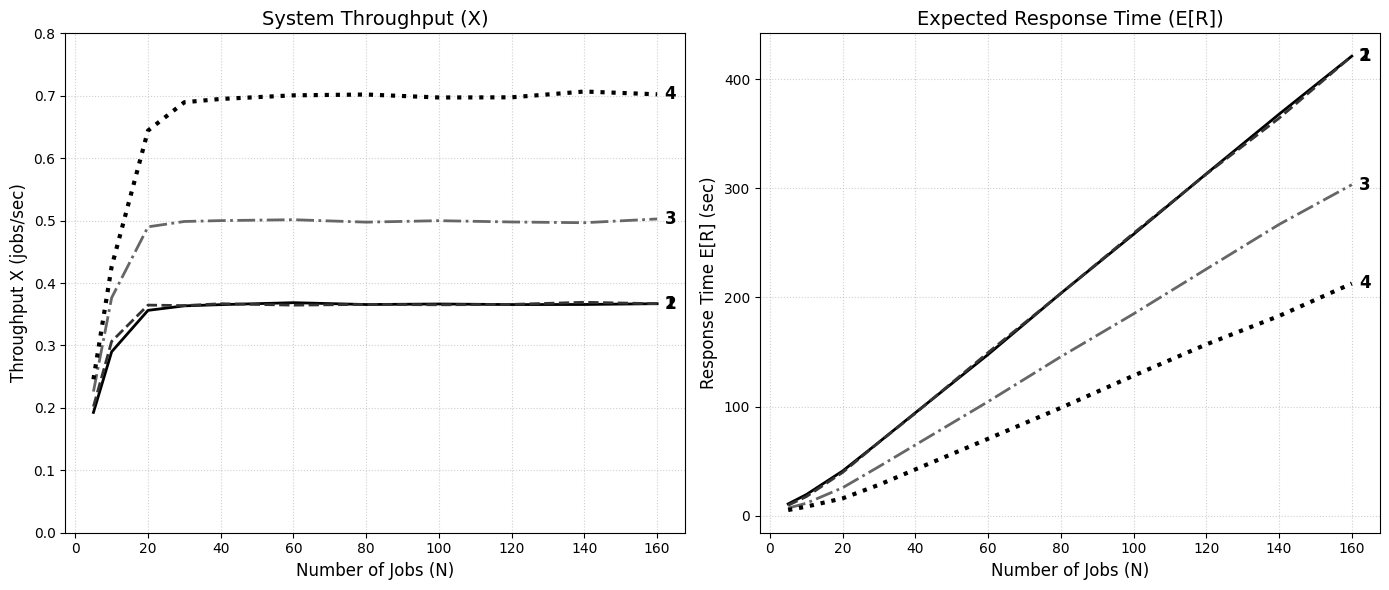

In [66]:
# Question 5: Performance Plots
# Comparison of all 4 scenarios

class ClosedQueueNetwork:
    def __init__(self, N_jobs=40, cpu_mean=2.0, num_fast_disks=1):
        self.env = simpy.Environment()
        self.cpu = simpy.Resource(self.env, capacity=1)
        self.slow_disk = simpy.Resource(self.env, capacity=1)
        
        self.fast_disks = [simpy.Resource(self.env, capacity=1) for _ in range(num_fast_disks)]
        
        self.N_jobs = N_jobs
        self.num_fast_disks = num_fast_disks
        self.beta_cpu = cpu_mean
        self.beta_fast_disk = 3.0
        self.beta_slow_disk = 30.0
        self.beta_rest = 15.0
        
        self.completed_cycles = 0
        
    def job_generator(self, job_id):
        while True:
            with self.cpu.request() as req:
                yield req
                yield self.env.timeout(RNG.exponential(scale=self.beta_cpu))

            disk, is_fast = self._select_disk()
            
            with disk.request() as req:
                yield req
                if is_fast:
                    yield self.env.timeout(RNG.exponential(scale=self.beta_fast_disk))
                else:
                    yield self.env.timeout(RNG.exponential(scale=self.beta_slow_disk))

            yield self.env.timeout(RNG.exponential(scale=self.beta_rest))
            self.completed_cycles += 1

    def _select_disk(self):
        fast_qs = [len(d.queue) for d in self.fast_disks]
        slow_q = len(self.slow_disk.queue)
        
        best_fast = min(fast_qs)
        best_idx = fast_qs.index(best_fast)
        
        if best_fast <= slow_q:
            return self.fast_disks[best_idx], True
        else:
            return self.slow_disk, False

    def run(self, until=100000):
        for i in range(self.N_jobs):
            self.env.process(self.job_generator(i))
        self.env.run(until=until)
        return self

    def get_throughput(self):
        return self.completed_cycles / self.env.now

    def get_response_time(self):
        X = self.get_throughput()
        if X > 0:
            return (self.N_jobs / X) - self.beta_rest
        return 0


def generate_plots():
    N_values = [5, 10, 20, 30, 40, 60, 80, 100, 120, 140, 160]
    sim_length = 50000
    n_reps = 3
    
    scenarios = [
        {"id": "1", "cpu": 2.0, "fast": 1},
        {"id": "2", "cpu": 1.0, "fast": 1},
        {"id": "3", "cpu": 2.0, "fast": 2},
        {"id": "4", "cpu": 1.0, "fast": 2}
    ]
    
    results = {s["id"]: {"X": [], "R": []} for s in scenarios}
    
    print("Running sims...")
    for sc in scenarios:
        print(f"  Scenario {sc['id']}...")
        for N in N_values:
            X_vals = []
            R_vals = []
            for _ in range(n_reps):
                net = ClosedQueueNetwork(
                    N_jobs=N, 
                    cpu_mean=sc["cpu"],
                    num_fast_disks=sc["fast"]
                )
                net.run(until=sim_length)
                X_vals.append(net.get_throughput())
                R_vals.append(net.get_response_time())
            
            results[sc["id"]]["X"].append(np.mean(X_vals))
            results[sc["id"]]["R"].append(np.mean(R_vals))

    # Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    styles = {
        "1": {"color": "black", "linestyle": "-", "linewidth": 2},
        "2": {"color": "#333333", "linestyle": "--", "linewidth": 2},
        "3": {"color": "#666666", "linestyle": "-.", "linewidth": 2},
        "4": {"color": "#000000", "linestyle": ":", "linewidth": 3}
    }

    # Throughput
    for sid in ["1", "2", "3", "4"]:
        ax1.plot(N_values, results[sid]["X"], **styles[sid])
        ax1.text(N_values[-1]+2, results[sid]["X"][-1], sid, fontsize=12, va='center', fontweight='bold')

    ax1.set_title("System Throughput (X)", fontsize=14)
    ax1.set_xlabel("Number of Jobs (N)", fontsize=12)
    ax1.set_ylabel("Throughput X (jobs/sec)", fontsize=12)
    ax1.set_ylim(0, 0.8)
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # Response Time
    for sid in ["1", "2", "3", "4"]:
        ax2.plot(N_values, results[sid]["R"], **styles[sid])
        ax2.text(N_values[-1]+2, results[sid]["R"][-1], sid, fontsize=12, va='center', fontweight='bold')

    ax2.set_title("Expected Response Time (E[R])", fontsize=14)
    ax2.set_xlabel("Number of Jobs (N)", fontsize=12)
    ax2.set_ylabel("Response Time E[R] (sec)", fontsize=12)
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.savefig('q5_final_plots.png', dpi=1000)
    print("\nSaved: q5_final_plots.png")


if __name__ == "__main__":
    generate_plots()


# 2. Open Queuing network simulation (8 pt)
The second part of the project is to make an open-queuing network simulator, where the jobs arrive from the outside following Poisson processes with the rate of lambda. The system is shown as the following figure:

![image](Figure.png)

Each job needs to go to the CPU, following an exponential distribution with a mean of 10 jobs per second, and then proceeds by either one of the disks. There are two disks, each of which has an exponentially-distributed processing time. The fast disk has a processing rate of 12 jobs per second and the slow disk has the rate of 9 jobs per second. The number of buffer spaces in each queue is infinite.


# Questions:
(4pt) Use your simulator to find the maximum sustainable throughput of such a system in terms of number of jobs. Support your answer with simulation results.

(4pt) Find out the average response times for following cases over three arrival rates of your choice: case (i) - a single queue in front of fast and slow disk; case (ii) - a separate queue for each disk, jointly applying the shortest queue load balancing strategy when sending the jobs from the CPU to disk.

![image](Figure_again.png)


In [67]:
class OpenNetwork:
    def __init__(self, env, cpu_rate, slow_rate, fast_rate):
        self.env = env
        self.cpu = simpy.Resource(env, capacity=1)
        self.slow_disk = simpy.Resource(env, capacity=1)
        self.fast_disk = simpy.Resource(env, capacity=1)
        self.cpu_rate = cpu_rate
        self.slow_rate = slow_rate
        self.fast_rate = fast_rate
        self.done = 0

    def job(self):
        with self.cpu.request() as req:
            yield req
            yield self.env.timeout(np.random.exponential(1/self.cpu_rate))
        # Pick disk at random
        if np.random.random() < 0.5:
            with self.slow_disk.request() as req:
                yield req
                yield self.env.timeout(np.random.exponential(1/self.slow_rate))
        else:
            with self.fast_disk.request() as req:
                yield req
                yield self.env.timeout(np.random.exponential(1/self.fast_rate))
        self.done += 1

def generate_jobs(env, system, lam):
    while True:
        yield env.timeout(np.random.exponential(1/lam))
        env.process(system.job())

def simulate(lam, sim_time=10000):
    env = simpy.Environment()
    system = OpenNetwork(env, cpu_rate=10, slow_rate=9, fast_rate=12)
    env.process(generate_jobs(env, system, lam))
    env.run(until=sim_time)
    return system.done / sim_time

# Test a range of λ
results = []
for lam in np.arange(5, 15, 1):
    avg_throughput = np.mean([simulate(lam) for _ in range(3)])
    results.append((lam, avg_throughput))
print(results)


[(np.int64(5), np.float64(4.9772)), (np.int64(6), np.float64(5.9773)), (np.int64(7), np.float64(7.010733333333334)), (np.int64(8), np.float64(8.000066666666667)), (np.int64(9), np.float64(9.054566666666666)), (np.int64(10), np.float64(9.973)), (np.int64(11), np.float64(9.983466666666667)), (np.int64(12), np.float64(9.997333333333334)), (np.int64(13), np.float64(10.0379)), (np.int64(14), np.float64(9.998933333333333))]


In [68]:
class OpenNetSplitDisks:
    """
    Open network with:
      - Poisson arrivals rate lambda_
      - 1 CPU: Exp service rate mucpu
      - 2 disks (fast, slow): Exp service rates mufast, muslow
        Each job: CPU -> (fast or slow) with prob 0.5 each, then leaves.
    """
    def __init__(self, lambda_: float, mucpu: float, mufast: float, muslow: float) -> None:
        self.env = simpy.Environment()
        self.beta_arr = 1.0 / lambda_
        self.beta_cpu = 1.0 / mucpu
        self.beta_fast = 1.0 / mufast
        self.beta_slow = 1.0 / muslow

        self.cpu = simpy.Resource(self.env, capacity=1)
        self.fast = simpy.Resource(self.env, capacity=1)
        self.slow = simpy.Resource(self.env, capacity=1)

        # stats
        self.n_curr_jobs = 0
        self.log_jobs_in_sys: list[int] = []

        self.et_acc = 0.0
        self.n_served_jobs = 0

        self.rho_cpu_acc = 0.0
        self.rho_fast_acc = 0.0
        self.rho_slow_acc = 0.0
        self.rho_sys_acc = 0.0

    # one job through CPU then one of the disks
    def system_generator(self) -> Generator:
        job_start_time = self.env.now

        # snapshot utilizations
        rho_cpu = self.cpu.count / self.cpu.capacity
        rho_fast = self.fast.count / self.fast.capacity
        rho_slow = self.slow.count / self.slow.capacity
        self.rho_cpu_acc += rho_cpu
        self.rho_fast_acc += rho_fast
        self.rho_slow_acc += rho_slow
        self.rho_sys_acc += (rho_cpu or rho_fast or rho_slow)

        self.log_jobs_in_sys.append(self.n_curr_jobs)
        self.n_curr_jobs += 1

        # CPU
        with self.cpu.request() as req:
            yield req
            yield self.env.timeout(RNG.exponential(scale=self.beta_cpu))

        # routing to disks (50/50)
        if RNG.random() < 0.5:
            disk = self.fast
            beta = self.beta_fast
        else:
            disk = self.slow
            beta = self.beta_slow

        with disk.request() as req:
            yield req
            yield self.env.timeout(RNG.exponential(scale=beta))

        self.n_curr_jobs -= 1
        self.et_acc += self.env.now - job_start_time
        self.n_served_jobs += 1

    # Poisson arrivals
    def job_generator(self) -> Generator:
        while True:
            yield self.env.timeout(RNG.exponential(self.beta_arr))
            self.env.process(self.system_generator())

    def run(self, t: float) -> "OpenNetSplitDisks":
        self.env.process(self.job_generator())
        self.env.run(until=t)
        return self

    # metrics (same style as OpenNet)
    def system_throughput(self) -> float:
        return self.n_served_jobs / self.env.now

    def utilization(self, comp: Literal["cpu", "fast", "slow", "sys"]) -> float:
        acc = {
            "cpu": self.rho_cpu_acc,
            "fast": self.rho_fast_acc,
            "slow": self.rho_slow_acc,
            "sys": self.rho_sys_acc,
        }[comp]
        return acc / len(self.log_jobs_in_sys)


In [69]:
def simulate_for_lambda(lambda_, sim_time=1000000):
    mucpu = 10.0         # CPU rate
    mufast = 12.0        # fast disk rate
    muslow = 9.0         # slow disk rate

    net = OpenNetSplitDisks(lambda_, mucpu, mufast, muslow).run(sim_time)
    return {
        "lambda": lambda_,
        "throughput": net.system_throughput(),
        "rho_cpu": net.utilization("cpu"),
        "rho_fast": net.utilization("fast"),
        "rho_slow": net.utilization("slow"),
        "rho_sys": net.utilization("sys"),
    }

lambdas = [7.0, 8.0, 8.5, 9.0, 9.5, 10.0]
results = [simulate_for_lambda(lmbd) for lmbd in lambdas]

for r in results:
    print(
        f"lambda={r['lambda']:4.1f}  "
        f"X={r['throughput']:.3f}  "
        f"rho_cpu={r['rho_cpu']:.3f}  "
        f"rho_fast={r['rho_fast']:.3f}  "
        f"rho_slow={r['rho_slow']:.3f}  "
        f"rho_sys={r['rho_sys']:.3f}"
    )


lambda= 7.0  X=7.001  rho_cpu=0.700  rho_fast=0.292  rho_slow=0.389  rho_sys=0.870
lambda= 8.0  X=8.001  rho_cpu=0.801  rho_fast=0.333  rho_slow=0.444  rho_sys=0.926
lambda= 8.5  X=8.495  rho_cpu=0.850  rho_fast=0.354  rho_slow=0.472  rho_sys=0.949
lambda= 9.0  X=8.999  rho_cpu=0.900  rho_fast=0.375  rho_slow=0.500  rho_sys=0.969
lambda= 9.5  X=9.504  rho_cpu=0.951  rho_fast=0.396  rho_slow=0.528  rho_sys=0.986
lambda=10.0  X=9.999  rho_cpu=0.999  rho_fast=0.417  rho_slow=0.555  rho_sys=1.000


In [70]:
class OpenNetSingleQueue:
    def __init__(self, lambda_, mucpu, mufast, muslow):
        self.env = simpy.Environment()
        self.beta_arr = 1.0 / lambda_
        self.beta_cpu = 1.0 / mucpu
        self.beta_fast = 1.0 / mufast
        self.beta_slow = 1.0 / muslow

        self.cpu = simpy.Resource(self.env, capacity=1)
        # single waiting line, but two disk servers behind it
        self.disk_queue = simpy.Store(self.env)
        self.fast = simpy.Resource(self.env, capacity=1)
        self.slow = simpy.Resource(self.env, capacity=1)

        self.et_acc = 0.0
        self.n_served_jobs = 0

        # start disk server processes
        self.env.process(self.disk_server(self.fast, self.beta_fast))
        self.env.process(self.disk_server(self.slow, self.beta_slow))

    def disk_server(self, disk_res: simpy.Resource, beta_disk: float) -> Generator:
        while True:
            job_start_time = yield self.disk_queue.get()   # get (start_time) from shared queue
            with disk_res.request() as req:
                yield req
                yield self.env.timeout(RNG.exponential(scale=beta_disk))
            # record response time
            self.et_acc += self.env.now - job_start_time
            self.n_served_jobs += 1

    def system_generator(self) -> Generator:
        job_start_time = self.env.now
        # CPU
        with self.cpu.request() as req:
            yield req
            yield self.env.timeout(RNG.exponential(scale=self.beta_cpu))
        # enqueue to common disk queue
        yield self.disk_queue.put(job_start_time)

    def job_generator(self) -> Generator:
        while True:
            yield self.env.timeout(RNG.exponential(self.beta_arr))
            self.env.process(self.system_generator())

    def run(self, T: float) -> "OpenNetSingleQueue":
        self.env.process(self.job_generator())
        self.env.run(until=T)
        return self

    def mean_response_time(self) -> float:
        return self.et_acc / self.n_served_jobs


In [71]:
def simulate_singlequeue_for_lambdas(lambdas, T=1000000):
    mucpu, mufast, muslow = 10.0, 12.0, 9.0
    for lam in lambdas:
        net = OpenNetSingleQueue(lam, mucpu, mufast, muslow).run(T)
        print(f"[single queue] lambda={lam:.1f},  E[T]={net.mean_response_time():.4f}")

lambdas = [5.0, 7.0, 8.5]
simulate_singlequeue_for_lambdas(lambdas)


[single queue] lambda=5.0,  E[T]=0.3024
[single queue] lambda=7.0,  E[T]=0.4407
[single queue] lambda=8.5,  E[T]=0.7852


In [72]:
class OpenNetShortestQueue:
    """
    Two separate disk queues; jobs from CPU join the shorter queue
    (ties broken randomly).
    """
    def __init__(self, lambda_, mucpu, mufast, muslow):
        self.env = simpy.Environment()
        self.beta_arr = 1.0 / lambda_
        self.beta_cpu = 1.0 / mucpu
        self.beta_fast = 1.0 / mufast
        self.beta_slow = 1.0 / muslow

        self.cpu = simpy.Resource(self.env, capacity=1)
        self.fast = simpy.Resource(self.env, capacity=1)
        self.slow = simpy.Resource(self.env, capacity=1)

        self.et_acc = 0.0
        self.n_served_jobs = 0

    def job_flow(self) -> Generator:
        job_start_time = self.env.now

        # CPU
        with self.cpu.request() as req:
            yield req
            yield self.env.timeout(RNG.exponential(scale=self.beta_cpu))

        # choose disk with shortest queue (including job in service)
        q_fast = len(self.fast.queue) + self.fast.count
        q_slow = len(self.slow.queue) + self.slow.count
        if q_fast < q_slow:
            disk, beta = self.fast, self.beta_fast
        elif q_slow < q_fast:
            disk, beta = self.slow, self.beta_slow
        else:  # tie
            if RNG.random() < 0.5:
                disk, beta = self.fast, self.beta_fast
            else:
                disk, beta = self.slow, self.beta_slow

        with disk.request() as req:
            yield req
            yield self.env.timeout(RNG.exponential(scale=beta))

        self.et_acc += self.env.now - job_start_time
        self.n_served_jobs += 1

    def job_generator(self) -> Generator:
        while True:
            yield self.env.timeout(RNG.exponential(self.beta_arr))
            self.env.process(self.job_flow())

    def run(self, T: float) -> "OpenNetShortestQueue":
        self.env.process(self.job_generator())
        self.env.run(until=T)
        return self

    def mean_response_time(self) -> float:
        return self.et_acc / self.n_served_jobs


In [73]:
def simulate_shortestqueue_for_lambdas(lambdas, T=1000000):
    mucpu, mufast, muslow = 10.0, 12.0, 9.0
    for lam in lambdas:
        net = OpenNetShortestQueue(lam, mucpu, mufast, muslow).run(T)
        print(f"[shortest queue] lambda={lam:.1f},  E[T]={net.mean_response_time():.4f}")

simulate_shortestqueue_for_lambdas(lambdas)


[shortest queue] lambda=5.0,  E[T]=0.3049
[shortest queue] lambda=7.0,  E[T]=0.4465
[shortest queue] lambda=8.5,  E[T]=0.7881
